In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def read_xyz(filename):
    with open(filename, "r") as f:
        lines = f.readlines()

    n_atoms = int(lines[0])

    coords = []

    for line in lines[2:]:
        parts = line.split()

        x = float(parts[1])
        y = float(parts[2])
        z = float(parts[3])

        coords.append([x, y, z])

    return np.array(coords), n_atoms

In [4]:
_, n_atoms = read_xyz("LJ13.xyz")

sigma = 1.0
epsilon = 1.0

In [5]:
def lj_energy(positions):

    N = n_atoms

    energy = 0.0

    for i in range(N):
        for j in range(i+1, N):

            rij = positions[i] - positions[j]

            r = np.linalg.norm(rij)

            energy += 4 * epsilon * ((sigma/r)**12 - (sigma/r)**6)

    return energy

In [6]:
def trial_move(positions, max_displacement):

    new_positions = positions.copy()

    atom = np.random.randint(n_atoms)

    displacement = np.random.uniform(-max_displacement, max_displacement, size=3)

    new_positions[atom] += displacement

    return new_positions

In [7]:
coords, _ = read_xyz("LJ13.xyz")
current_energy = lj_energy(coords)

temperature = 0.10

n_steps = 10000000

accepted_moves = 0

energy_history = []

configs = []

for step in range(n_steps):

    new_coords = trial_move(coords, 0.07)

    E_new = lj_energy(new_coords)

    deltaE = E_new - current_energy

    if deltaE <= 0:
        accept = True

    else:
        probability = np.exp(-deltaE / temperature)

        accept = np.random.rand() < probability


    if accept:
        coords = new_coords
        current_energy = E_new
        accepted_moves += 1

    #if step % 100 == 0:
     #   print(f"Step {step}, Energy: {current_energy}")
    
    energy_history.append(current_energy)

    if step > 5000 and step % 2000 == 0:
        configs.append(coords.copy())

print(f"Total accepted moves: {accepted_moves} out of {n_steps}")
print(f"Acceptance percentage: {accepted_moves*100/n_steps:.2f}%")

Total accepted moves: 2976307 out of 10000000
Acceptance percentage: 29.76%


Text(0.5, 1.0, 'Convergence check (burn-in diagnostic)')

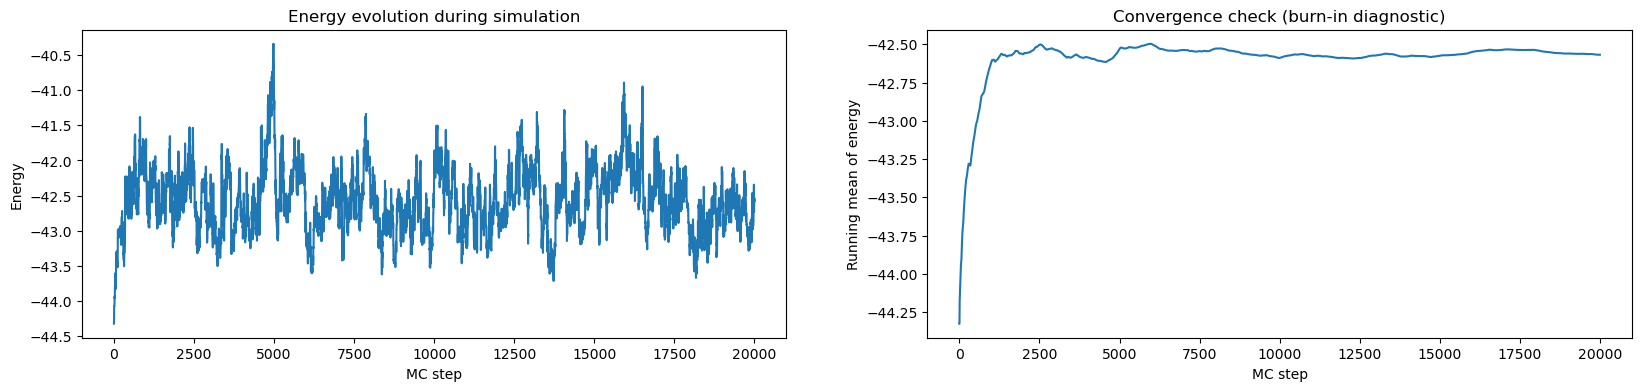

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(20, 4))
ax[0].plot(energy_history[:20000])
ax[0].set_xlabel("MC step")
ax[0].set_ylabel("Energy")
ax[0].set_title("Energy evolution during simulation")

running_mean = np.cumsum(energy_history) / np.arange(1, len(energy_history)+1)

ax[1].plot(running_mean[:20000])
ax[1].set_xlabel("MC step")
ax[1].set_ylabel("Running mean of energy")
ax[1].set_title("Convergence check (burn-in diagnostic)")

The energy and cumulative mean at each MC step shows that a burn-in of 10000 is reasonable

In [10]:
def flyvbjerg_petersen(data):

    data = np.asarray(data, dtype=float).copy()

    block_sizes = []
    standard_errors = []
    variances = []

    block_size = 1

    while len(data) >= 16:

        n = len(data)

        variance = np.var(data, ddof=1)

        error = np.sqrt(variance / n)

        block_sizes.append(block_size)
        standard_errors.append(error)
        variances.append(variance)

        if n % 2 == 1:
            data = data[:-1]

        data = 0.5 * (data[0::2] + data[1::2])

        block_size *= 2

    return np.array(block_sizes), np.array(standard_errors), np.array(variances)

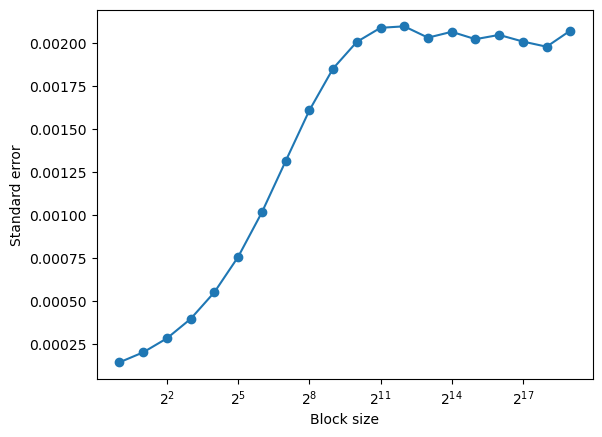

In [11]:
production_energy = energy_history[10000:]

block_sizes, errors, variances = flyvbjerg_petersen(production_energy)

plt.plot(block_sizes, errors, marker='o')
plt.xscale('log', base=2)
plt.xlabel("Block size")
plt.ylabel("Standard error")
plt.show()

A block size of 2048 is where a "plateau" is apparent 

In [12]:
for b,e in zip(block_sizes, errors):
    print(b,e)

1 0.0001415962018436732
2 0.0001996459136670906
4 0.00028108406944486394
8 0.00039431155352880233
16 0.0005491970322052942
32 0.000754664724652781
64 0.0010134099703244756
128 0.0013111160441174811
256 0.0016065325602859536
512 0.0018503321151257645
1024 0.002005370786231494
2048 0.002087417183496135
4096 0.002096114199562538
8192 0.002030197586897033
16384 0.002064200961533357
32768 0.002021274678997076
65536 0.0020461681891621006
131072 0.002007552052749614
262144 0.0019774487904017255
524288 0.002071377230290817


In [13]:
energies = []

for config in configs:
    energies.append(lj_energy(config))

energies = np.array(energies)

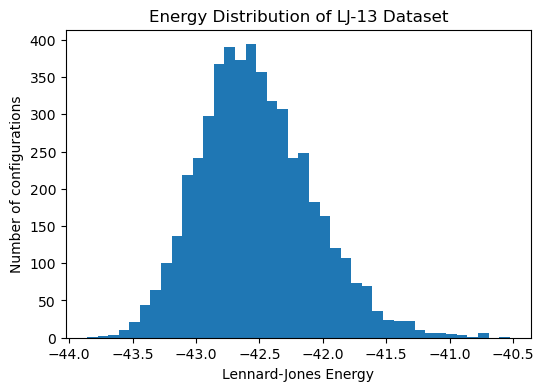

In [14]:
plt.figure(figsize=(6,4))

plt.hist(energies, bins=40)

plt.xlabel("Lennard-Jones Energy")
plt.ylabel("Number of configurations")
plt.title("Energy Distribution of LJ-13 Dataset")

plt.show()

The energies of the "independent" samples follow a distribution as shown. As a temperature (T=0.1) is chosen, the energy most visited is higher than the initial minimum energy

In [15]:
print("Minimum energy :", np.min(energies))
print("Maximum energy :", np.max(energies))
print("Mean energy    :", np.mean(energies))
print("Std deviation  :", np.std(energies))

Minimum energy : -43.85945072480158
Maximum energy : -40.5259202441543
Mean energy    : -42.52203899262035
Std deviation  : 0.4469855617200676


In [17]:
pair_distances = []

for config in configs:

    for i in range(n_atoms):

        for j in range(i+1, n_atoms):

            r = np.linalg.norm(config[i] - config[j])

            pair_distances.append(r)

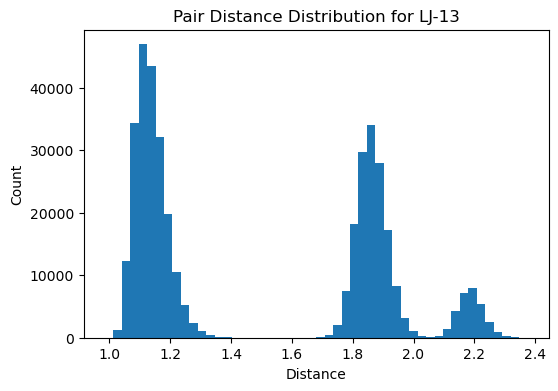

In [18]:
plt.figure(figsize=(6,4))

plt.hist(pair_distances, bins=50)

plt.xlabel("Distance")
plt.ylabel("Count")
plt.title("Pair Distance Distribution for LJ-13")

plt.show()

The pair distance / radial distrbution shows that there are three different distances between the atoms based on the relative positions of the atoms in the icosahedron